# PEMS 全区 传感器网络增长 & 邻接矩阵快照 可视化

把 `pems03 ~ pems12` 各个 district 放在一张 **3×4 网格**里，每个子图展示：
- 主曲线：历年传感器数量（N）增长
- 右下内嵌：若干年份的邻接矩阵缩略图（binary view），直接叠在曲线对应位置

数据来源：
- 节点数：从 `pemsXX/pemsXX_YYYY_flow.csv` 第一行列数推算（排除 Timestamp 列）
- 邻接矩阵：`preprocessed/pemsXX/graph/{year}_adj.npz` key=`x`（缺失则跳过）

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings("ignore")

# ========= 配置 =========
DISTRICTS = ["pems03", "pems04", "pems05", "pems06",
             "pems07", "pems08", "pems10", "pems11", "pems12"]

BASE_DIR = "."                             # 工作目录 = xxltrafficdata/
PREPROC  = os.path.join(BASE_DIR, "preprocessed")

# 快照年份（若该年无数据则自动跳过）
SNAPSHOT_YEARS = [2005, 2012, 2018, 2025]

# 颜色配置
COLORS = plt.cm.tab10(np.linspace(0, 1, len(DISTRICTS)))

print(f"Districts: {len(DISTRICTS)} -> {DISTRICTS}")
print(f"Snapshot years: {SNAPSHOT_YEARS}")

Districts: 9 -> ['pems03', 'pems04', 'pems05', 'pems06', 'pems07', 'pems08', 'pems10', 'pems11', 'pems12']
Snapshot years: [2005, 2012, 2018, 2025]


## Step 1: 收集每个 district 的年度节点数 & 邻接矩阵快照

In [2]:
def scan_years(district_dir, district):
    """从 CSV 文件名中提取可用年份，并用第一行列数推算 N（快，不读完整 CSV）"""
    result = {}
    if not os.path.isdir(district_dir):
        return result
    for fname in sorted(os.listdir(district_dir)):
        if not (fname.startswith(f"{district}_") and fname.endswith("_flow.csv")):
            continue
        try:
            year = int(fname.replace(f"{district}_", "").replace("_flow.csv", ""))
        except ValueError:
            continue
        fpath = os.path.join(district_dir, fname)
        with open(fpath, "r") as f:
            header = f.readline()
        ncols = len(header.rstrip("\n").split(","))
        result[year] = ncols - 1  # 去掉 Timestamp 列
    return result


def load_adj_snapshots(district, years):
    """加载指定年份的邻接矩阵（若不存在则跳过）"""
    gdir = os.path.join(PREPROC, district, "graph")
    snaps = {}
    if not os.path.isdir(gdir):
        return snaps
    for y in years:
        fp = os.path.join(gdir, f"{y}_adj.npz")
        if os.path.exists(fp):
            snaps[y] = np.load(fp)["x"]
    return snaps


data = {}
for d in DISTRICTS:
    ddir = os.path.join(BASE_DIR, d)
    nodes_by_year = scan_years(ddir, d)
    snaps = load_adj_snapshots(d, SNAPSHOT_YEARS)
    data[d] = {"nodes": nodes_by_year, "adj": snaps}
    years_str = f"{min(nodes_by_year)}-{max(nodes_by_year)}" if nodes_by_year else "N/A"
    print(f"[{d}] years={years_str} ({len(nodes_by_year)} yrs) "
          f"adj_snapshots={list(snaps.keys())}")

[pems03] years=2001-2025 (25 yrs) adj_snapshots=[]
[pems04] years=N/A (0 yrs) adj_snapshots=[]
[pems05] years=N/A (0 yrs) adj_snapshots=[]
[pems06] years=N/A (0 yrs) adj_snapshots=[]
[pems07] years=N/A (0 yrs) adj_snapshots=[]
[pems08] years=N/A (0 yrs) adj_snapshots=[]
[pems10] years=N/A (0 yrs) adj_snapshots=[]
[pems11] years=N/A (0 yrs) adj_snapshots=[]
[pems12] years=N/A (0 yrs) adj_snapshots=[]


## Step 2: 3×4 网格总览

前 9 格：各 district 的增长曲线 + 邻接矩阵缩略图；  
最后 3 格：全局对比（所有 district 叠加、总节点数、平均连接度）

saved -> pems_all_growth_viz.png


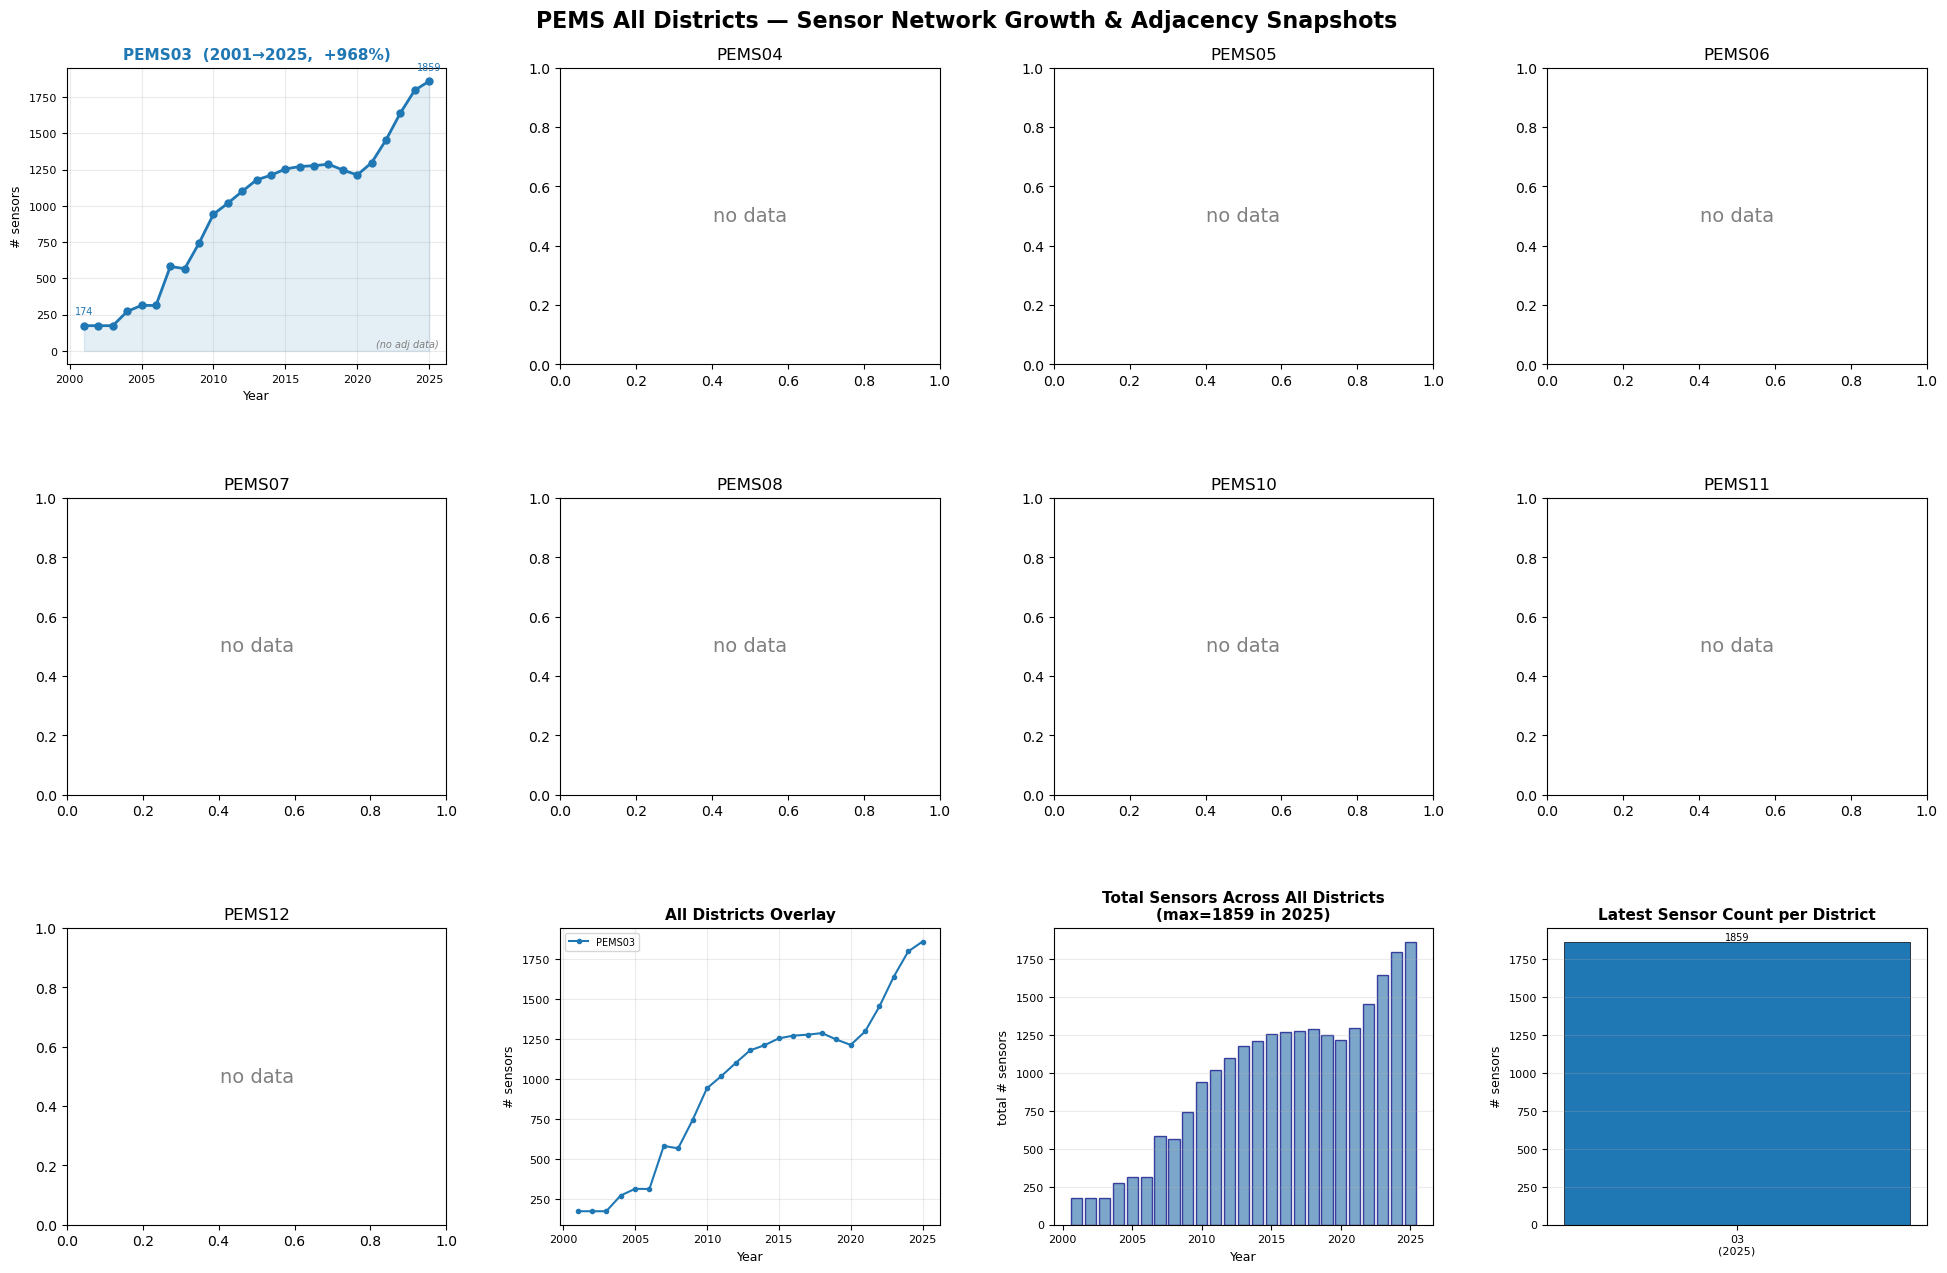

In [3]:
fig = plt.figure(figsize=(20, 13))
gs  = fig.add_gridspec(3, 4, hspace=0.45, wspace=0.30,
                       left=0.05, right=0.98, top=0.94, bottom=0.05)

# ------ 前 9 格：每个 district 一张子图 ------
for i, d in enumerate(DISTRICTS):
    row, col = divmod(i, 4)
    ax = fig.add_subplot(gs[row, col])
    color = COLORS[i]

    nodes = data[d]["nodes"]
    snaps = data[d]["adj"]
    if not nodes:
        ax.text(0.5, 0.5, "no data", ha="center", va="center",
                transform=ax.transAxes, fontsize=14, color="gray")
        ax.set_title(d.upper())
        continue

    years = sorted(nodes.keys())
    ncnt  = [nodes[y] for y in years]

    # 主曲线：节点增长
    ax.plot(years, ncnt, "o-", color=color, linewidth=2, markersize=5, zorder=2)
    ax.fill_between(years, ncnt, alpha=0.12, color=color, zorder=1)
    ax.set_xlabel("Year", fontsize=9)
    ax.set_ylabel("# sensors", fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.tick_params(labelsize=8)

    # 起止年份节点数标注
    ax.annotate(f"{ncnt[0]}", (years[0], ncnt[0]),
                textcoords="offset points", xytext=(0, 8), fontsize=7,
                ha="center", color=color)
    ax.annotate(f"{ncnt[-1]}", (years[-1], ncnt[-1]),
                textcoords="offset points", xytext=(0, 8), fontsize=7,
                ha="center", color=color)

    # 标题：district + 年份跨度 + 节点增长比例
    growth_pct = (ncnt[-1] / ncnt[0] - 1) * 100 if ncnt[0] > 0 else 0
    ax.set_title(f"{d.upper()}  ({years[0]}→{years[-1]},  +{growth_pct:.0f}%)",
                 fontsize=11, color=color, fontweight="bold")

    # 内嵌邻接矩阵缩略图：放在该年份对应的曲线点下方的 inset
    avail_snap_years = [y for y in SNAPSHOT_YEARS if y in snaps and y in nodes]
    if avail_snap_years:
        # 把 insets 水平排列在子图底部区域
        n_ins = len(avail_snap_years)
        bbox = ax.get_position()
        ins_w = (bbox.width - 0.01 * (n_ins - 1)) / n_ins * 0.85
        ins_h = ins_w * fig.get_figwidth() / fig.get_figheight()  # 保持近似方形
        ins_h = min(ins_h, bbox.height * 0.35)
        y_pos = bbox.y0 + bbox.height * 0.04
        x_start = bbox.x0 + bbox.width * 0.08
        step = (bbox.width * 0.84) / n_ins
        for k, sy in enumerate(avail_snap_years):
            ax_ins = fig.add_axes([x_start + k * step, y_pos, ins_w, ins_h])
            adj = snaps[sy]
            ax_ins.imshow(adj > 0, cmap="Blues", aspect="auto", interpolation="nearest")
            ax_ins.set_xticks([])
            ax_ins.set_yticks([])
            ax_ins.set_title(f"{sy}·N={adj.shape[0]}", fontsize=7, pad=1.5)
            for spine in ax_ins.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(0.8)

            # 在主曲线上标出该快照对应的年份
            if sy in nodes:
                ax.scatter([sy], [nodes[sy]], s=60,
                           facecolor="white", edgecolor=color,
                           linewidth=1.8, zorder=3)
    else:
        ax.text(0.98, 0.05, "(no adj data)", ha="right", va="bottom",
                transform=ax.transAxes, fontsize=7, color="gray", style="italic")

# ------ 最后 3 格：全局汇总 ------

# [2,1]: 所有 district 的增长曲线叠加
ax_all = fig.add_subplot(gs[2, 1])
for i, d in enumerate(DISTRICTS):
    nodes = data[d]["nodes"]
    if not nodes:
        continue
    years = sorted(nodes.keys())
    ax_all.plot(years, [nodes[y] for y in years], "o-",
                color=COLORS[i], label=d.upper(), markersize=3, linewidth=1.5)
ax_all.set_title("All Districts Overlay", fontsize=11, fontweight="bold")
ax_all.set_xlabel("Year", fontsize=9)
ax_all.set_ylabel("# sensors", fontsize=9)
ax_all.legend(fontsize=7, ncol=2, loc="upper left")
ax_all.grid(True, alpha=0.25)
ax_all.tick_params(labelsize=8)

# [2,2]: 每年所有 district 的节点总和
ax_sum = fig.add_subplot(gs[2, 2])
all_years = sorted(set(y for d in DISTRICTS for y in data[d]["nodes"]))
totals = [sum(data[d]["nodes"].get(y, 0) for d in DISTRICTS) for y in all_years]
bars = ax_sum.bar(all_years, totals, color="steelblue", alpha=0.7, edgecolor="navy")
ax_sum.set_title(f"Total Sensors Across All Districts\n(max={max(totals)} in {all_years[np.argmax(totals)]})",
                 fontsize=11, fontweight="bold")
ax_sum.set_xlabel("Year", fontsize=9)
ax_sum.set_ylabel("total # sensors", fontsize=9)
ax_sum.grid(True, alpha=0.25, axis="y")
ax_sum.tick_params(labelsize=8)

# [2,3]: 每个 district 在 2025（或最后可用年份）的节点数柱状图
ax_bar = fig.add_subplot(gs[2, 3])
latest_N = []
labels = []
bar_colors = []
for i, d in enumerate(DISTRICTS):
    if not data[d]["nodes"]:
        continue
    last_year = max(data[d]["nodes"].keys())
    latest_N.append(data[d]["nodes"][last_year])
    labels.append(f"{d.upper()[-2:]}\n({last_year})")
    bar_colors.append(COLORS[i])
b = ax_bar.bar(range(len(latest_N)), latest_N, color=bar_colors, edgecolor="black", linewidth=0.5)
ax_bar.set_xticks(range(len(labels)))
ax_bar.set_xticklabels(labels, fontsize=7)
ax_bar.set_title("Latest Sensor Count per District", fontsize=11, fontweight="bold")
ax_bar.set_ylabel("# sensors", fontsize=9)
ax_bar.grid(True, alpha=0.25, axis="y")
ax_bar.tick_params(labelsize=8)
for rect, v in zip(b, latest_N):
    ax_bar.text(rect.get_x() + rect.get_width() / 2, rect.get_height(),
                f"{v}", ha="center", va="bottom", fontsize=7)

fig.suptitle("PEMS All Districts — Sensor Network Growth & Adjacency Snapshots",
             fontsize=16, fontweight="bold", y=0.985)

plt.savefig("pems_all_growth_viz.pdf", dpi=200, bbox_inches="tight")
print("saved -> pems_all_growth_viz.png")
plt.show()

## Step 3: （可选）单独放大某个 district 的邻接矩阵演化

如果想仔细看邻接矩阵的结构变化，可以单独画一个 district 所有快照年份的并排大图。

saved -> pems11_adj_evolution.png


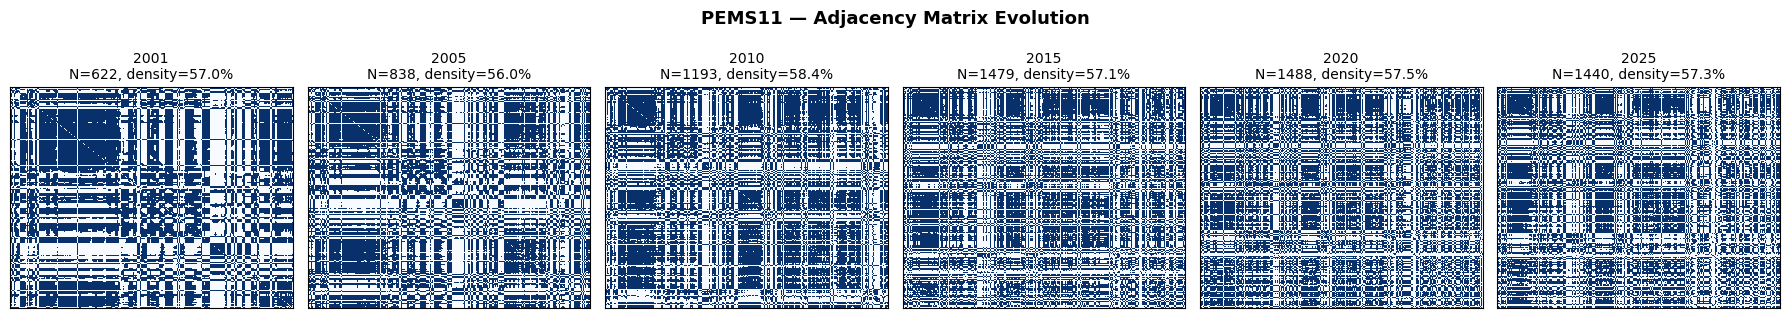

In [4]:
ZOOM_DISTRICT = "pems11"   # 改成你想细看的 district
ZOOM_YEARS    = [2001, 2005, 2010, 2015, 2020, 2025]

gdir = os.path.join(PREPROC, ZOOM_DISTRICT, "graph")
avail = [y for y in ZOOM_YEARS if os.path.exists(os.path.join(gdir, f"{y}_adj.npz"))]

if avail:
    fig2, axes2 = plt.subplots(1, len(avail), figsize=(3 * len(avail), 3.2))
    if len(avail) == 1:
        axes2 = [axes2]
    for ax, y in zip(axes2, avail):
        adj = np.load(os.path.join(gdir, f"{y}_adj.npz"))["x"]
        ax.imshow(adj > 0, cmap="Blues", aspect="auto", interpolation="nearest")
        density = (adj > 0).sum() / (adj.shape[0] ** 2) * 100
        ax.set_title(f"{y}\nN={adj.shape[0]}, density={density:.1f}%", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
    fig2.suptitle(f"{ZOOM_DISTRICT.upper()} — Adjacency Matrix Evolution",
                  fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{ZOOM_DISTRICT}_adj_evolution.png", dpi=120, bbox_inches="tight")
    print(f"saved -> {ZOOM_DISTRICT}_adj_evolution.png")
    plt.show()
else:
    print(f"No adj snapshots available for {ZOOM_DISTRICT} in {ZOOM_YEARS}")